In [61]:
import numpy as np
import pandas as pd
import ROOT
import seaborn as sns
from neuland_add_random_hitpar import NeulandRandHitParAdder as ParAdder
from neuland_read_hit_par import HitParReader as ParReader
from scipy import stats

In [79]:
canvas = ROOT.TCanvas("canvas", "canvas", 1200, 500)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas


In [2]:
input_par_file = "/lustre/r3b/ywang/test/neuland_test/millepede/sim40M.par.root"
output_par_file = "/lustre/r3b/ywang/test/neuland_test/millepede/sim_added.par.root"

In [48]:
NUMBER_OF_BARS = 1300

par_adder = ParAdder(NUMBER_OF_BARS)
period = 150

par_adder.effective_speed.set_cos(offset=15, amp=5, period=period, err=0.1)
par_adder.t_sync.set_cos(offset=200, amp=50, period=period, err=1)
par_adder.t_diff.set_cos(offset=50, amp=25, period=period, err=0.5)
par_adder.light_attenuation_length.set_cos(offset=150, amp=10, period=period, err=1)
par_adder.energy_gain.set_cos(offset=15.0, amp=5.0, period=period, err=0.5)
par_adder.pedestal.set_cos(offset=25.0, amp=5.0, period=period, err=0.5)
par_adder.pmt_thresh.set_cos(offset=0.75, amp=0.25, period=period, err=0.5)
par_adder.saturation_coefficient.set_cos(offset=0.5, amp=0.4, period=period, err=0.5)

par_adder.insert_parameters(input_par_file, output_par_file)

Error in <TClass::New>: cannot create object of class R3B::Neuland::TrackGenerator
Error in <TBufferFile::ReadObject>: could not create object of class R3B::Neuland::TrackGenerator
Error in <TBufferFile::CheckByteCount>: object of class TObjArray read too few bytes: 66 instead of 96
Info in <TGeoManager::CloseGeometry>: Geometry loaded from file...
Info in <TGeoManager::SetTopVolume>: Top volume is cave. Master volume is cave
Info in <TGeoNavigator::BuildCache>: --- Maximum geometry depth set to 100
Info in <TGeoManager::Voxelize>: Voxelizing...
Info in <TGeoManager::CountLevels>: max level = 3, max placements = 1300
Info in <TGeoManager::CloseGeometry>: 5202 nodes/ 6 volume UID's in FAIR geometry
Info in <TGeoManager::CloseGeometry>: ----------------modeler ready----------------


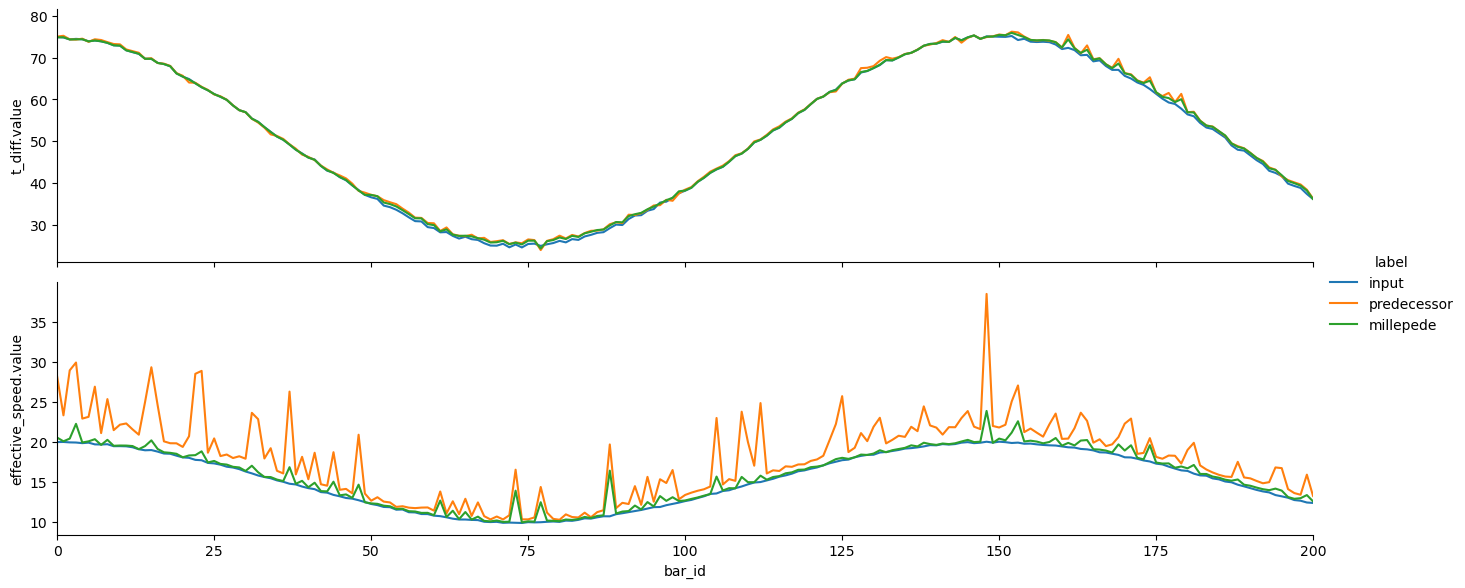

In [140]:
g = sns.PairGrid(
    data=par_df,
    x_vars=["bar_id"],
    y_vars=["t_diff.value", "effective_speed.value"],
    hue="label",
    height=3,
    aspect=4.5,
)
g.map_offdiag(sns.lineplot)
g.add_legend()
g.set(xlim=(0, 200))

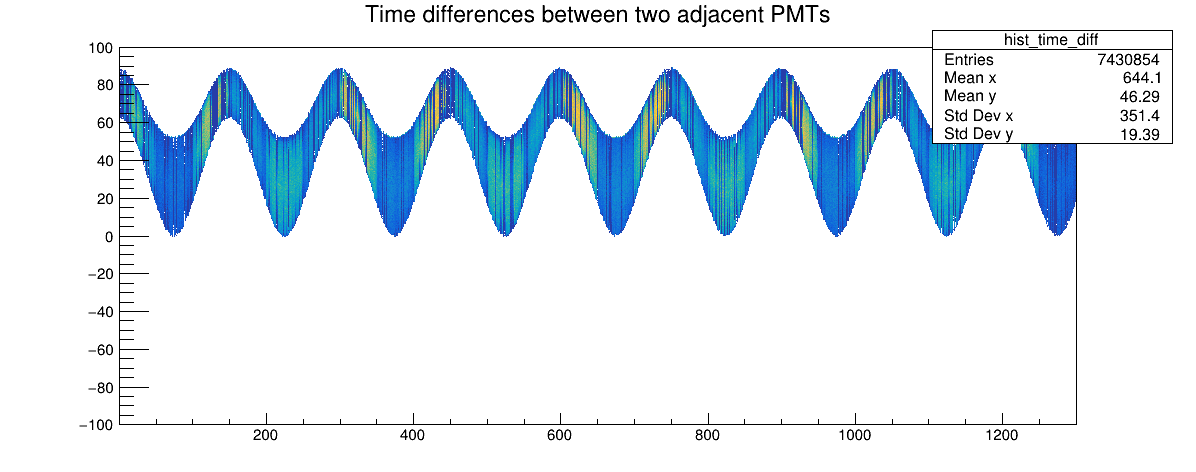

In [80]:
cal_data_file = ROOT.TFile(
    "/lustre/r3b/ywang/test/neuland_test/millepede/cal.output.root", "read"
)
hist = cal_data_file.Get("DataMonitor/NeulandCal2HitParTask").Get("hist_time_diff")
hist.Draw()
canvas.Draw()

In [53]:
fitter = ROOT.Fit.Fitter()
func = ROOT.TF1("f1", "pol1", 0, 130)
fitter.SetFunction(ROOT.Math.WrappedMultiTF1(func, func.GetNdim()), True)
fitter.Config().SetMinimizer("Linear")
# fitter.Config().ParSettings().Set("slope", 0, 0.01, )
option = fitter.Config().MinimizerOptions()
fitter.Config().MinimizerOptions().SetPrintLevel(0)

In [66]:
x = np.array([127.5, 117.5, 107.5, 97.5, 87.5, 77.5, 67.5, 47.5])
x_err = np.array([2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5])
y = np.array([107.5, 87.5, 107.5, 102.5, 102.5, 102.5, 102.5, 102.5])
y_err = np.array([2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5])

bin_data = ROOT.Fit.BinData(len(x), x, y, x_err, y_err)

In [67]:
ROOT.gErrorIgnoreLevel = ROOT.kFatal
ROOT.RooMsgService.instance().setGlobalKillBelow(ROOT.RooFit.FATAL)
fitter.Config().ParSettings(0).SetValue(0.0)
fitter.Config().ParSettings(1).SetValue(1.0)
# fitter.Config().ParSettings(0).SetUpperLimit(10000)
# fitter.Config().ParSettings(0).SetLowerLimit(-10000)
# fitter.Config().ParSettings(1).SetUpperLimit(10000)
# fitter.Config().ParSettings(1).SetLowerLimit(-10000)
is_ok = fitter.Fit(bin_data)
print(f"is ok: {is_ok}")
root_res = fitter.Result()
print(f"slope: {root_res.Parameter(1)}")
print(f"offset: {root_res.Parameter(0)}")
print(f"pvalue: {root_res.Prob()}")


res = stats.linregress(x, y)
print("\n\npython results:")
print(f"slope: {res.slope}")
print(f"offset: {res.intercept}")
print(f"pvalue: {res.pvalue}")

is ok: True
slope: -0.026315789473679532
offset: 104.27631578947322
pvalue: 1.2110317366528042e-07


python results:
slope: -0.02631578947368421
offset: 104.27631578947368
pvalue: 0.7904465907386824


<Axes: xlabel='value', ylabel='y'>

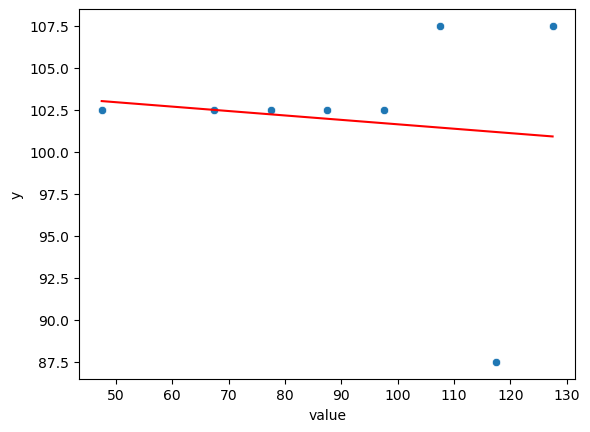

In [68]:
dataframe_1 = pd.DataFrame({"value": x, "y": y, "label": "raw"})
func_x = np.linspace(min(x), max(x), 100)
dataframe_2 = pd.DataFrame(
    {
        "value": func_x,
        "y": func_x * root_res.Parameter(1) + root_res.Parameter(0),
        "label": "function",
    }
)
sns.scatterplot(data=dataframe_1, x="value", y="y")
sns.lineplot(data=dataframe_2, x="value", y="y", color="r")

In [124]:
c_value_1 = []
a_value_1 = []
b_value_1 = []
c_value_2 = []
a_value_2 = []
b_value_2 = []

c_value_2.append(-11.376180911407587)
a_value_2.append(8.25)
b_value_2.append(1)
c_value_1.append(-8.25)
a_value_1.append(7.75)
b_value_1.append(1)
c_value_2.append(-6.482116747297802)
a_value_2.append(7.25)
b_value_2.append(1)
c_value_1.append(-5)
a_value_1.append(6.75)
b_value_1.append(1)
c_value_1.append(11.5)
a_value_1.append(1.75)
b_value_1.append(1)
c_value_2.append(11.350394902555085)
a_value_2.append(2.25)
b_value_2.append(1)
c_value_2.append(7.820902870315479)
a_value_2.append(3.25)
b_value_2.append(1)
c_value_1.append(6.25)
a_value_1.append(3.75)
b_value_1.append(1)
c_value_2.append(4.240780741799384)
a_value_2.append(4.25)
b_value_2.append(1)
c_value_1.append(3)
a_value_1.append(4.75)
b_value_1.append(1)
c_value_2.append(0.7357278986761511)
a_value_2.append(5.25)
b_value_2.append(1)
c_value_1.append(-0.5)
a_value_1.append(5.75)
b_value_1.append(1)

<Axes: xlabel='x', ylabel='y'>

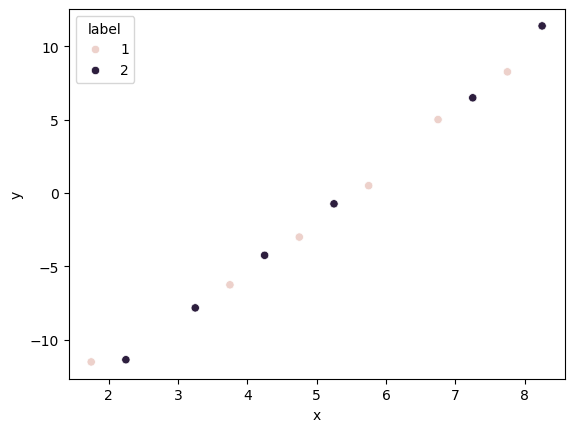

In [126]:
sns.scatterplot(data, x="x", y="y", hue="label")